## Visualizing Mouse and Cricket Hunting Traces

This notebook creates a static hunt-trace figure from analysis CSV output.

**Workflow**
1. Opens a folder picker (Tkinter GUI).
2. Finds one CSV in that folder (`*_analysis_full.csv` preferred, then `*_pythonAnalysis.csv`).
3. Loads framewise tracking data and finds the capture boundary (`captured`).
4. Applies a frame window using `start_frame` and plots data in `[start_frame, capture_frame)`.
5. Draws mouse and cricket paths in arena-adjusted coordinates (`madj_*`, `cadj_*`).
6. Marks start and end points for each trace and draws the arena outline.
7. Saves the figure as both `*_hunt_trace.svg` and `*_hunt_trace.pdf`.

**Adjustable Parameters (Step 2 cell)**
- `arena_width`, `arena_height`: arena dimensions for clipping/plot bounds.
- `start_frame`: first frame to include in the trace.
- `mouse_color_rgb`, `cricket_color_rgb`: path/marker colors.

**Outputs**
- Vector trace plots (`.svg`, `.pdf`) saved to the selected folder.

**Notes**
- If no capture event is found, the full trial is used.
- Y-axis is inverted to match video coordinate convention (origin at top-left).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tkinter as tk
from tkinter import filedialog
import os
import glob

### Step 1: Select the Data Folder
Run the cell below to open a dialog box. Navigate to and select the folder that contains your `_analysis_full.csv` (or `_pythonAnalysis.csv`) file.

In [2]:
# Set up the root Tkinter window
root = tk.Tk()
root.withdraw() # Hide the main window

# --- Set the initial directory ---
# If 'last_folder_path' was loaded and the directory still exists, use it.
# Otherwise, start at the current working directory.
if 'last_folder_path' in locals() and os.path.isdir(last_folder_path):
    initial_dir = last_folder_path
else:
    initial_dir = os.getcwd()

# Open the dialog to ask for a directory
print("Please select the folder containing your analysis files...")
folder_path = filedialog.askdirectory(
    title='Select Folder',
    initialdir=initial_dir
)

if not folder_path:
    print("No folder selected. Notebook execution stopped.")
else:
    print(f"Selected folder: {folder_path}")
    # --- Save the newly selected folder path for the next run ---
    last_folder_path = folder_path
    %store last_folder_path

Please select the folder containing your analysis files...


2026-03-01 11:51:44.867 python[23253:1489265] The class 'NSOpenPanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


Selected folder: /Volumes/David_1/predation_mouse/test_mouse
Stored 'last_folder_path' (str)


### Step 2: Load Data and Generate Plot
This cell will find the CSV file, process the data, create the plot, and save it.

Loading data from: ChAT-V1_hM4#2M_D7post_T4DeepCut_resnet50_CricketMar21shuffle1_100000_analysis_full.csv
Plotting frames 0 to 151 (capture at frame 151)
Figure saved to: 
/Volumes/David_1/predation_mouse/test_mouse/ChAT-V1_hM4#2M_D7post_T4DeepCut_resnet50_CricketMar21shuffle1_100000_hunt_trace.svg
/Volumes/David_1/predation_mouse/test_mouse/ChAT-V1_hM4#2M_D7post_T4DeepCut_resnet50_CricketMar21shuffle1_100000_hunt_trace.pdf


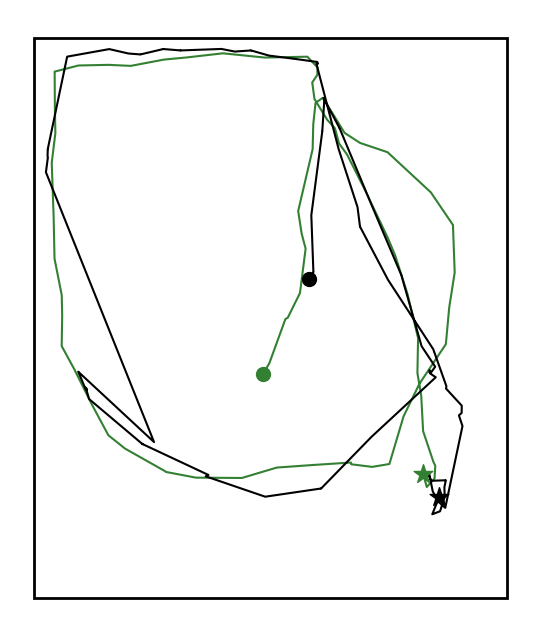

In [ ]:

if folder_path: # Proceed only if a folder was selected
    try:
        # --- Adjustable Parameters ---
        arena_width = 45
        arena_height = 38
        start_frame = 0  # Starting frame for traces (0 = beginning)
        # Set trace colors in [R, G, B] format (0-255)
        mouse_color_rgb = [51, 128, 51]
        cricket_color_rgb = [0, 0, 0]
        
        # Normalize colors for Matplotlib
        mouse_color = np.array(mouse_color_rgb) / 255.0
        cricket_color = np.array(cricket_color_rgb) / 255.0
        
        # --- CORRECTED File Handling ---
        # 1. Look for the primary file type first
        primary_pattern = os.path.join(folder_path, '*_analysis_full.csv')
        csv_files = glob.glob(primary_pattern)
        
        # 2. If primary is not found, look for the fallback file type
        if not csv_files:
            fallback_pattern = os.path.join(folder_path, '*_pythonAnalysis.csv')
            csv_files = glob.glob(fallback_pattern)

        # 3. If neither is found, raise an error
        if not csv_files:
            raise FileNotFoundError("Could not find a file ending with '_analysis_full.csv' or '_pythonAnalysis.csv' in the selected folder.")
        
        csv_path = csv_files[0] # Use the first file found
        print(f"Loading data from: {os.path.basename(csv_path)}")
        
        # Load the dataframe
        df = pd.read_csv(csv_path)
        
        # Find the capture frame
        capture_frame = df[df['captured'].diff() == 1].first_valid_index()
        
        if capture_frame is None:
            print("Warning: No capture frame found. Using the entire trial duration.")
            capture_frame = len(df)
            
        # --- Data Preparation ---
        # Slice the dataframe from start_frame up to capture_frame
        effective_start = max(int(start_frame), 0)
        effective_end = max(int(capture_frame), effective_start + 1)
        hunt_df = df.iloc[effective_start:effective_end].copy()
        if hunt_df.empty:
            raise ValueError(f"No frames to plot after applying start_frame={effective_start} and capture_frame={capture_frame}.")
        print(f"Plotting frames {effective_start} to {effective_end} (capture at frame {capture_frame})")
        
        # Get mouse and cricket traces
        mouse_x = hunt_df['madj_x']
        mouse_y = hunt_df['madj_y']
        cricket_x = hunt_df['cadj_x']
        cricket_y = hunt_df['cadj_y']
        
        # 1. Map positions outside the arena to the closest border point
        mouse_x = np.clip(mouse_x, 0, arena_width)
        mouse_y = np.clip(mouse_y, 0, arena_height)
        cricket_x = np.clip(cricket_x, 0, arena_width)
        cricket_y = np.clip(cricket_y, 0, arena_height)
        
        # --- Plotting ---
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # 2. Plot the traces
        ax.plot(mouse_x, mouse_y, color=mouse_color)
        ax.plot(cricket_x, cricket_y, color=cricket_color)
        
        # 3. Put circles and stars at the start and end of traces (matching trace color)
        # Mouse markers
        ax.scatter(mouse_x.iloc[0], mouse_y.iloc[0], marker='o', color=mouse_color, s=100, zorder=5)
        ax.scatter(mouse_x.iloc[-1], mouse_y.iloc[-1], marker='*', color=mouse_color, s=200, zorder=5)
        
        # Cricket markers
        ax.scatter(cricket_x.iloc[0], cricket_y.iloc[0], marker='o', color=cricket_color, s=100, zorder=5)
        ax.scatter(cricket_x.iloc[-1], cricket_y.iloc[-1], marker='*', color=cricket_color, s=200, zorder=5)
        
        # 4. Show the outline of the arena
        arena = patches.Rectangle((0, 0), arena_width, arena_height, linewidth=2, edgecolor='black', facecolor='none')
        ax.add_patch(arena)
        
        # --- Final Touches ---
        ax.set_aspect('equal', adjustable='box')
        ax.invert_yaxis() # Often in video coordinates, origin is top-left
        # 5. Remove gridlines and axes
        ax.axis('off')
        
        # 6. Save the figure
        # Handle both possible input filenames when creating the output name
        base_filename = os.path.splitext(os.path.basename(csv_path))[0].replace('_analysis_full', '').replace('_pythonAnalysis', '')
        save_path_svg = os.path.join(folder_path, f"{base_filename}_hunt_trace.svg")
        save_path_pdf = os.path.join(folder_path, f"{base_filename}_hunt_trace.pdf")
        
        # Use a tight bounding box to remove extra white space
        plt.savefig(save_path_svg, format='svg', bbox_inches='tight', pad_inches=0)
        plt.savefig(save_path_pdf, format='pdf', bbox_inches='tight', pad_inches=0)
        
        print(f"Figure saved to: \n{save_path_svg}\n{save_path_pdf}")
        
        plt.show()
        
    except Exception as e:
        print(f"An error occurred: {e}")